In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df  = pd.read_csv('datasets/steamdb_top_sellers_2019-2024.csv')
df

,Tahun Rilis,Rank,Nama Game,Diskon,Harga,Rating,Tanggal Rilis,Followers,Online Saat Ini,Peak Pemain
0,2019,46.0,Destiny 2,0%,Free,79.01%,01 Oct,"719,675","23,683","316,750"
1,2019,50.0,Hunt: Showdown 1896,-50%,Rp 127500,72.01%,27 Aug,"487,821","11,991","60,124"
2,2019,78.0,STAR WARS Jedi: Fallen Order™,-75%,Rp 119750,87.54%,15 Nov,"205,752","2,262","46,550"
3,2019,81.0,Blasphemous,-90%,Rp 19999,88.56%,10 Sep,"90,902","2,274","3,465"
4,2019,121.0,Oxygen Not Included,-70%,Rp 35999,95.39%,30 Jul,"396,429","10,600","27,486"
...,...,...,...,...,...,...,...,...,...,...
595,2024,513.0,Buckshot Roulette,0%,Rp 28999,94.55%,04 Apr,"66,069",842,"20,226"
596,2024,519.0,Crusader Kings III: Roads to Power,0%,Rp 321999,80.49%,24 Sep,—,—,—
597,2024,532.0,Void Crew,0%,Rp 219000,85.42%,25 Nov,"56,198",692,"4,722"
598,2024,540.0,Abiotic Factor,0%,Rp 284999,94.38%,02 May,"99,658","1,494","21,753"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tahun Rilis      600 non-null    int64  
 1   Rank             600 non-null    float64
 2   Nama Game        600 non-null    object 
 3   Diskon           600 non-null    object 
 4   Harga            600 non-null    object 
 5   Rating           600 non-null    object 
 6   Tanggal Rilis    600 non-null    object 
 7   Followers        600 non-null    object 
 8   Online Saat Ini  600 non-null    object 
 9   Peak Pemain      600 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 47.0+ KB


In [8]:
# Mengubah kolom menjadi numerik

# Membersihkan kolom 'Harga' dari teks dan simbol mata uang
df['Harga'] = df['Harga'].astype(str).str.lower().replace({'free to play': '0', 'free': '0'}, regex=False)
df['Harga'] = df['Harga'].str.replace(r'[^\d.]', '', regex=True)
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce').fillna(0)

# Membersihkan dan mengubah kolom persentase
for col in ['Diskon', 'Rating']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Membersihkan dan mengubah kolom angka dengan koma
for col in ['Followers', 'Online Saat Ini', 'Peak Pemain']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Menampilkan tipe data setelah konversi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tahun Rilis      600 non-null    int64  
 1   Rank             600 non-null    float64
 2   Nama Game        600 non-null    object 
 3   Diskon           600 non-null    int64  
 4   Harga            600 non-null    float64
 5   Rating           600 non-null    float64
 6   Tanggal Rilis    600 non-null    object 
 7   Followers        600 non-null    float64
 8   Online Saat Ini  600 non-null    float64
 9   Peak Pemain      600 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 47.0+ KB


In [9]:
df

,Tahun Rilis,Rank,Nama Game,Diskon,Harga,Rating,Tanggal Rilis,Followers,Online Saat Ini,Peak Pemain
0,2019,46.0,Destiny 2,0,0.0,79.01,01 Oct,719675.0,23683.0,316750.0
1,2019,50.0,Hunt: Showdown 1896,-50,127500.0,72.01,27 Aug,487821.0,11991.0,60124.0
2,2019,78.0,STAR WARS Jedi: Fallen Order™,-75,119750.0,87.54,15 Nov,205752.0,2262.0,46550.0
3,2019,81.0,Blasphemous,-90,19999.0,88.56,10 Sep,90902.0,2274.0,3465.0
4,2019,121.0,Oxygen Not Included,-70,35999.0,95.39,30 Jul,396429.0,10600.0,27486.0
...,...,...,...,...,...,...,...,...,...,...
595,2024,513.0,Buckshot Roulette,0,28999.0,94.55,04 Apr,66069.0,842.0,20226.0
596,2024,519.0,Crusader Kings III: Roads to Power,0,321999.0,80.49,24 Sep,0.0,0.0,0.0
597,2024,532.0,Void Crew,0,219000.0,85.42,25 Nov,56198.0,692.0,4722.0
598,2024,540.0,Abiotic Factor,0,284999.0,94.38,02 May,99658.0,1494.0,21753.0


In [20]:
# 1. Mengubah nama kolom menjadi format snake_case
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 2. Membuat kolom 'apakah_diskon'
# Jika diskon bukan 0, maka 1, selain itu 0
df['apakah_diskon'] = (df['diskon'] != 0).astype(int)

# 3. Membuat kolom 'apakah_gratis'
# Jika harga adalah 0, maka 1, selain itu 0
df['apakah_gratis'] = (df['harga'] == 0).astype(int)

# 4. Menggabungkan dan mengonversi kolom tanggal
# Menggabungkan string dari tanggal dan tahun
df['tanggal_rilis_lengkap'] = df['tanggal_rilis'].astype(str) + ' ' + df['tahun_rilis'].astype(str)
# Mengonversi ke format datetime, menangani kemungkinan error
df['tanggal_rilis_lengkap'] = pd.to_datetime(df['tanggal_rilis_lengkap'], format='%d %b %Y', errors='coerce')

# 5. Membuat kolom 'selling_rank' berdasarkan tahun dari tanggal yang baru
df['selling_rank'] = df.groupby(df['tanggal_rilis_lengkap'].dt.year).cumcount() + 1

# 6. Menghapus kolom asli yang sudah tidak diperlukan
df.drop(columns=['tanggal_rilis', 'tahun_rilis'], inplace=True)

# Menampilkan beberapa baris pertama dengan kolom baru
df

KeyError: 'tanggal_rilis'

In [21]:
df

,rank,nama_game,diskon,harga,rating,followers,online_saat_ini,peak_pemain,apakah_diskon,apakah_gratis,selling_rank,tanggal_rilis_lengkap
0,46.0,Destiny 2,0,0.0,79.01,719675.0,23683.0,316750.0,0,1,1,2019-10-01
1,50.0,Hunt: Showdown 1896,-50,127500.0,72.01,487821.0,11991.0,60124.0,1,0,2,2019-08-27
2,78.0,STAR WARS Jedi: Fallen Order™,-75,119750.0,87.54,205752.0,2262.0,46550.0,1,0,3,2019-11-15
3,81.0,Blasphemous,-90,19999.0,88.56,90902.0,2274.0,3465.0,1,0,4,2019-09-10
4,121.0,Oxygen Not Included,-70,35999.0,95.39,396429.0,10600.0,27486.0,1,0,5,2019-07-30
...,...,...,...,...,...,...,...,...,...,...,...,...
595,513.0,Buckshot Roulette,0,28999.0,94.55,66069.0,842.0,20226.0,0,0,96,2024-04-04
596,519.0,Crusader Kings III: Roads to Power,0,321999.0,80.49,0.0,0.0,0.0,0,0,97,2024-09-24
597,532.0,Void Crew,0,219000.0,85.42,56198.0,692.0,4722.0,0,0,98,2024-11-25
598,540.0,Abiotic Factor,0,284999.0,94.38,99658.0,1494.0,21753.0,0,0,99,2024-05-02


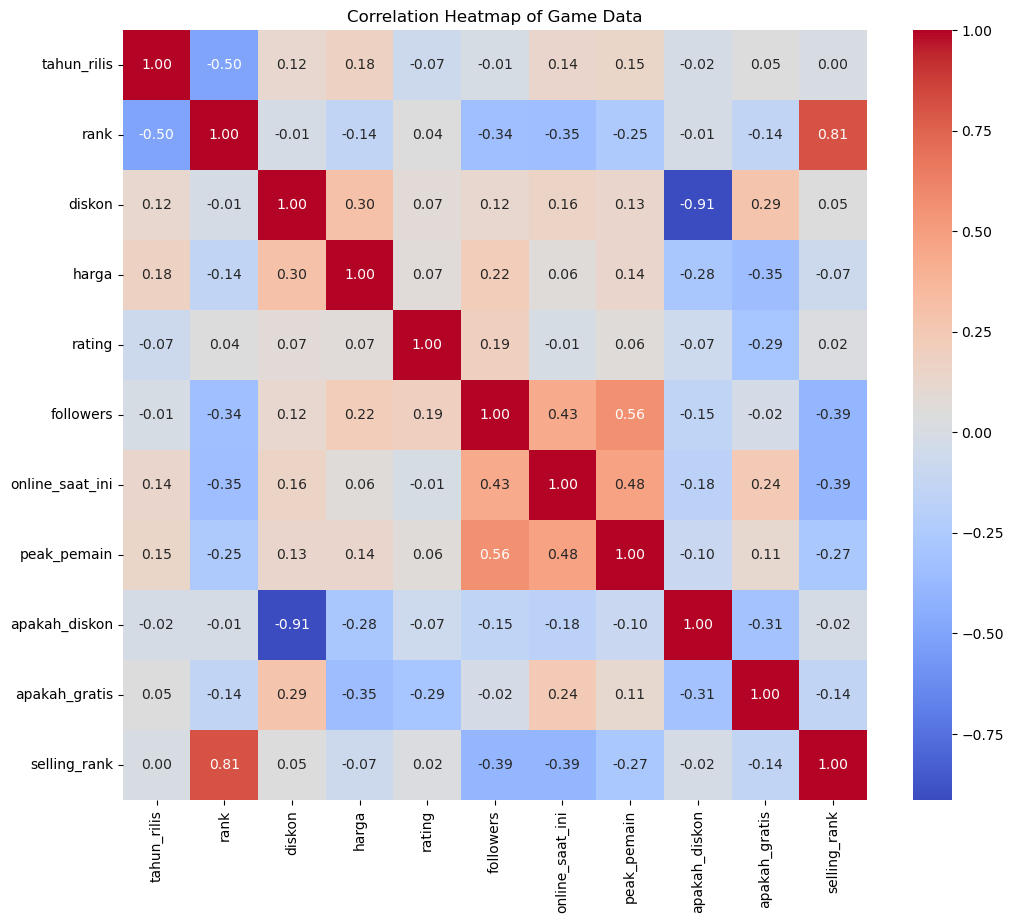

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Game Data')
plt.show()